# **Capstone project: Providing data-driven suggestions for HR**

## Project Overview

Salifort Motors wants to better understand employee turnover and identify practical ways to improve retention. This project explores HR data, builds classification models to predict whether an employee is likely to leave, and translates the model results into stakeholder-ready recommendations.


## Dataset

The dataset contains employee-level HR records, including satisfaction, evaluation scores, project load, average monthly hours, tenure, work accidents, promotion history, department, salary, and whether the employee left the company.


## Imports and Data Loading


### Import packages

In [3]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score,\
precision_score, recall_score, f1_score

In [4]:
# Load dataset into a dataframe
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Display first few rows of the dataframe
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Data Exploration and Cleaning


### Gather basic information about the data

In [5]:
# Gather basic information about the data
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [6]:
# Gather descriptive statistics about the data
df0.describe(include='all')

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999,14999
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4140,7316
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,NaN,NaN
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN


### Standardize Column Names


In [7]:
# Display all column names
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [8]:
# Rename columns for clarity and consistency
df0=df0.rename(columns={'number_project':'no_of_projects','average_montly_hours':'avg_monthly_hours',
                       'time_spend_company':'service_tenure','Work_accident':'work_accident_nos',
                       'left':'left_company','Department':'department'})
# Display all column names after the update
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'no_of_projects',
       'avg_monthly_hours', 'service_tenure', 'work_accident_nos',
       'left_company', 'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Missing Values


In [9]:
# Check for missing values
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
no_of_projects           0
avg_monthly_hours        0
service_tenure           0
work_accident_nos        0
left_company             0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Duplicate Records


In [10]:
# Check for duplicates
df0.duplicated().sum()

np.int64(3008)

In [11]:
# Inspect which rows are flagged as duplicates
df0.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
14994     True
14995     True
14996     True
14997     True
14998     True
Length: 14999, dtype: bool

In [12]:
# Drop duplicate rows and save the result in a new dataframe
df=df0.drop_duplicates()

# Display the first few rows of the deduplicated dataframe
df.head()

,satisfaction_level,last_evaluation,no_of_projects,avg_monthly_hours,service_tenure,work_accident_nos,left_company,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Outlier Check


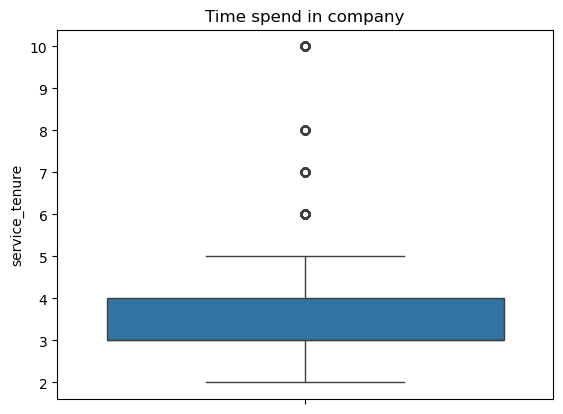

In [13]:
# Create a boxplot to visualize the distribution of `service_tenure` and detect outliers
sns.boxplot(df['service_tenure'])
plt.title('Time spend in company')
plt.show()

In [14]:
# Determine the number of rows containing outliers
q1=df['service_tenure'].quantile(0.25)
q3=df['service_tenure'].quantile(0.75)
iqr=q3-q1
Lower_limit=q1-1.5*iqr
Upper_limit=q3+1.5*iqr
print('Lower Limit: ',Lower_limit)
print('Upper Limit: ',Upper_limit)
outliers=df[(df['service_tenure']<Lower_limit)|(df['service_tenure']>Upper_limit)]
print('Number of outliers: ',len(outliers))

Lower Limit:  1.5
Upper Limit:  5.5
Number of outliers:  824


## Exploratory Data Analysis


### Employee Turnover Rate


In [15]:
# Get numbers of people who left vs. stayed
print(df['left_company'].value_counts())

# Get percentages of people who left vs. stayed
print("")
print(100*df['left_company'].value_counts(normalize=True))

left_company
0    10000
1     1991
Name: count, dtype: int64

left_company
0    83.39588
1    16.60412
Name: proportion, dtype: float64


### Visual Analysis


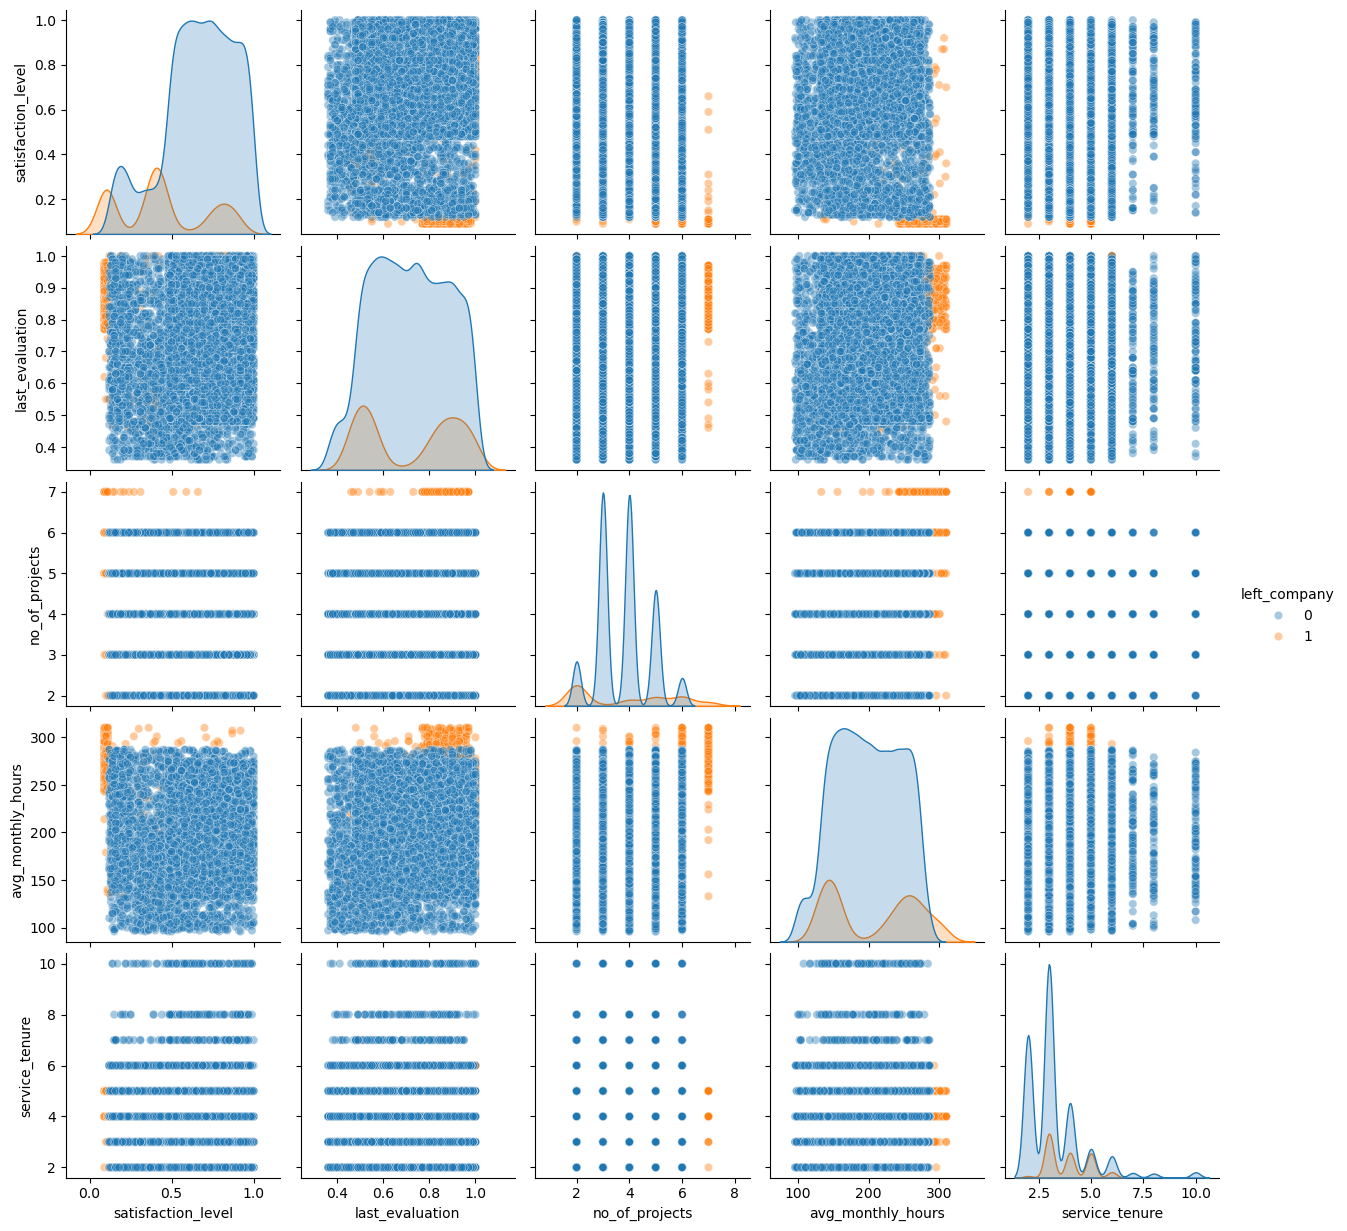

In [16]:
# Pairwise relationships among the key numeric variables, colored by attrition
sns.pairplot(
    df,
    vars=['satisfaction_level', 'last_evaluation', 'no_of_projects',
          'avg_monthly_hours', 'service_tenure'],
    hue='left_company',
    plot_kws={'alpha': 0.4}
)
plt.show()

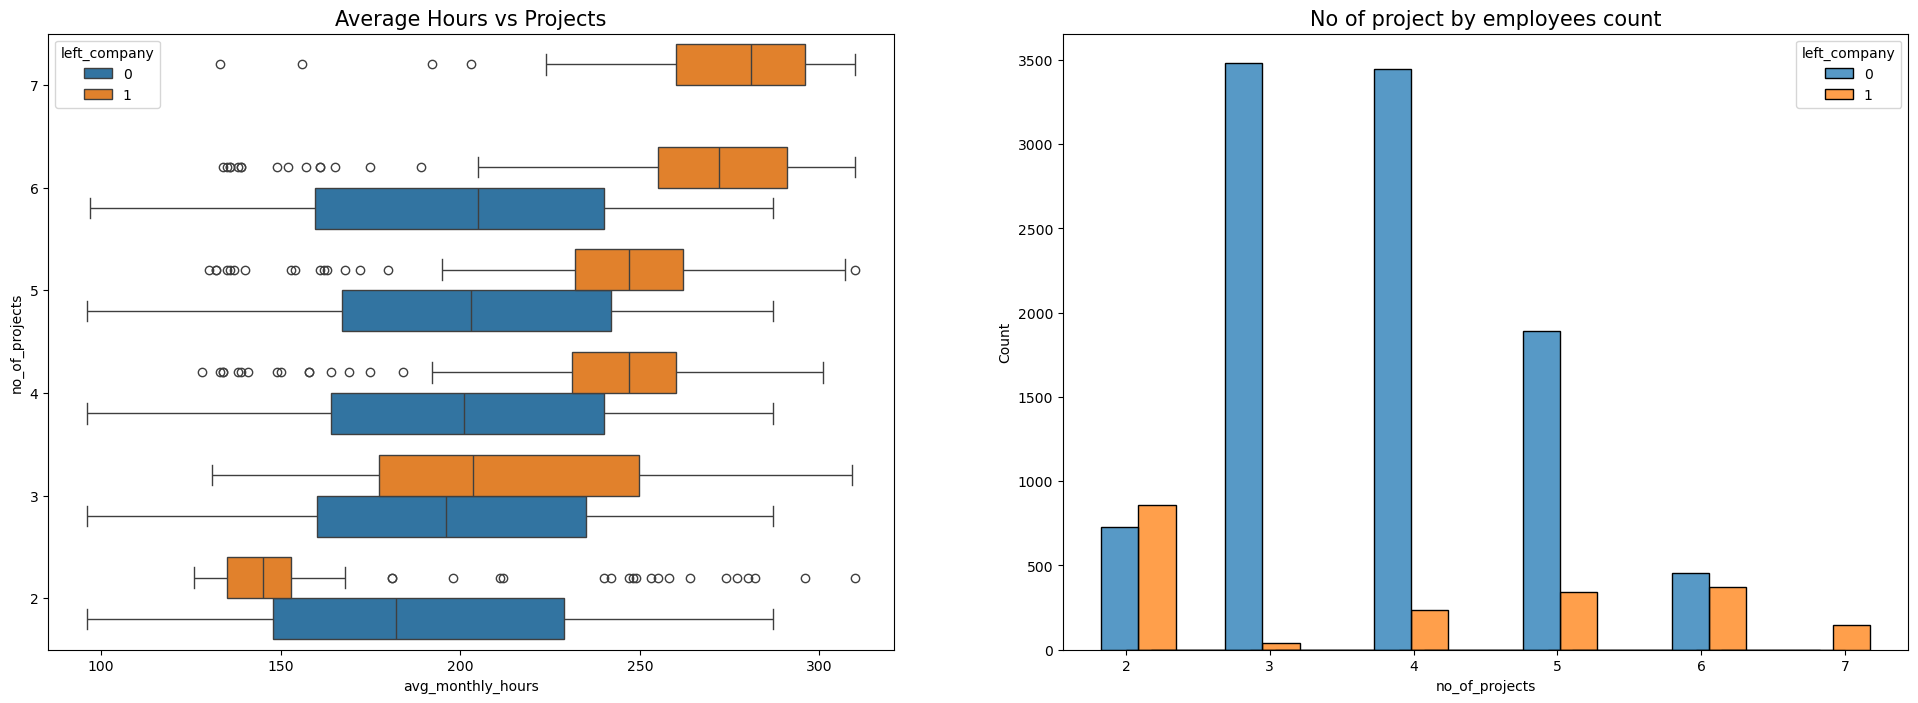

In [17]:
# Compare average monthly hours and project load for leavers vs stayers
fig,ax=plt.subplots(1,2,figsize=(24,8))

sns.boxplot(data=df,x='avg_monthly_hours',y='no_of_projects',hue='left_company',orient='h',ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Average Hours vs Projects', fontsize='15')

sns.histplot(data=df,x='no_of_projects',hue='left_company', multiple='dodge',shrink=3,ax=ax[1])
ax[1].set_title('No of project by employees count', fontsize='15')
plt.show()

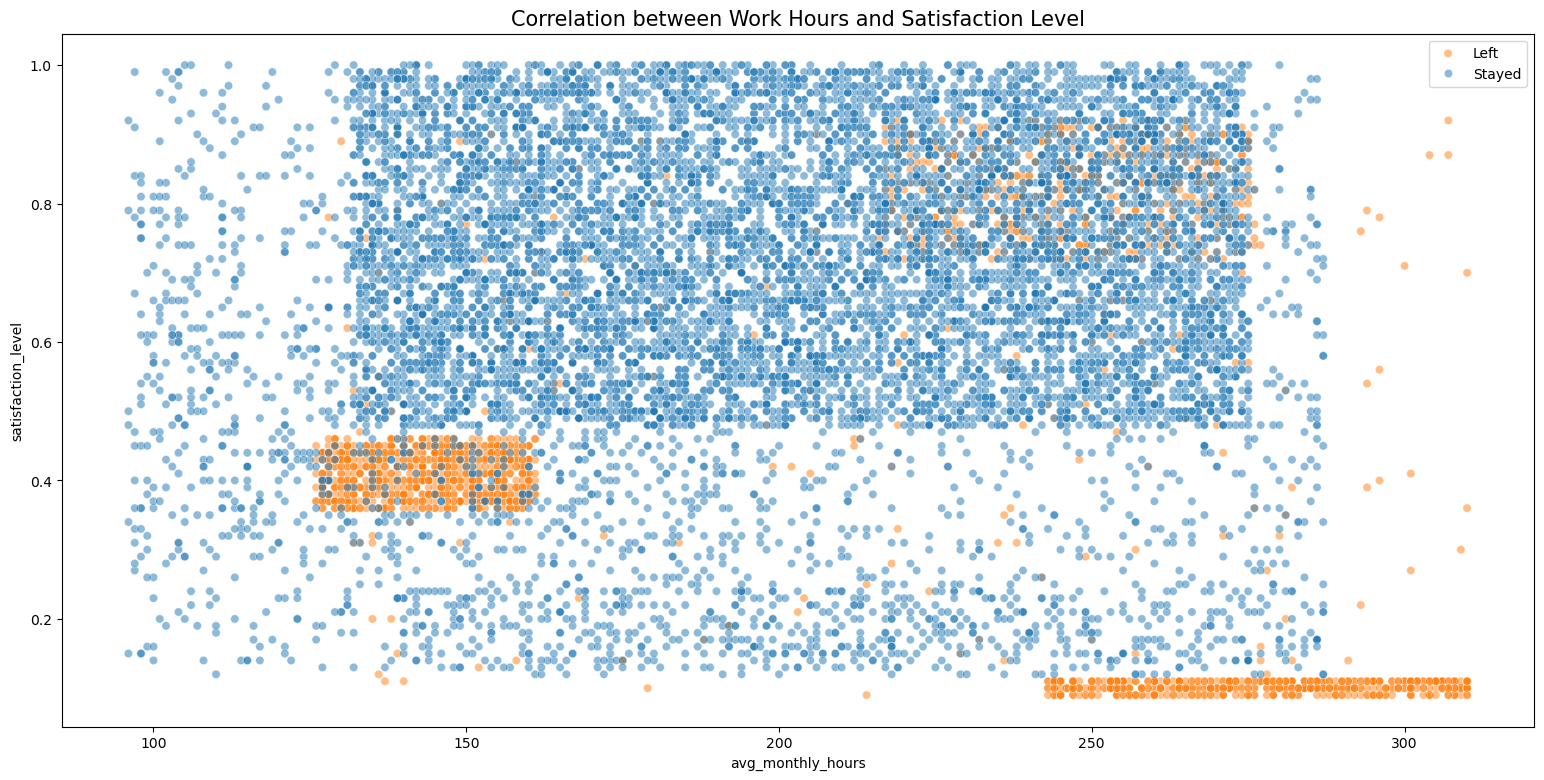

In [18]:
# Relationship between monthly hours and satisfaction level, colored by attrition
plt.figure(figsize=(19,9))
sns.scatterplot(data=df,x='avg_monthly_hours',y='satisfaction_level',hue='left_company',alpha=0.5)
plt.title('Correlation between Work Hours and Satisfaction Level',fontsize=15)
plt.legend(labels=['Left','Stayed'])
plt.show()

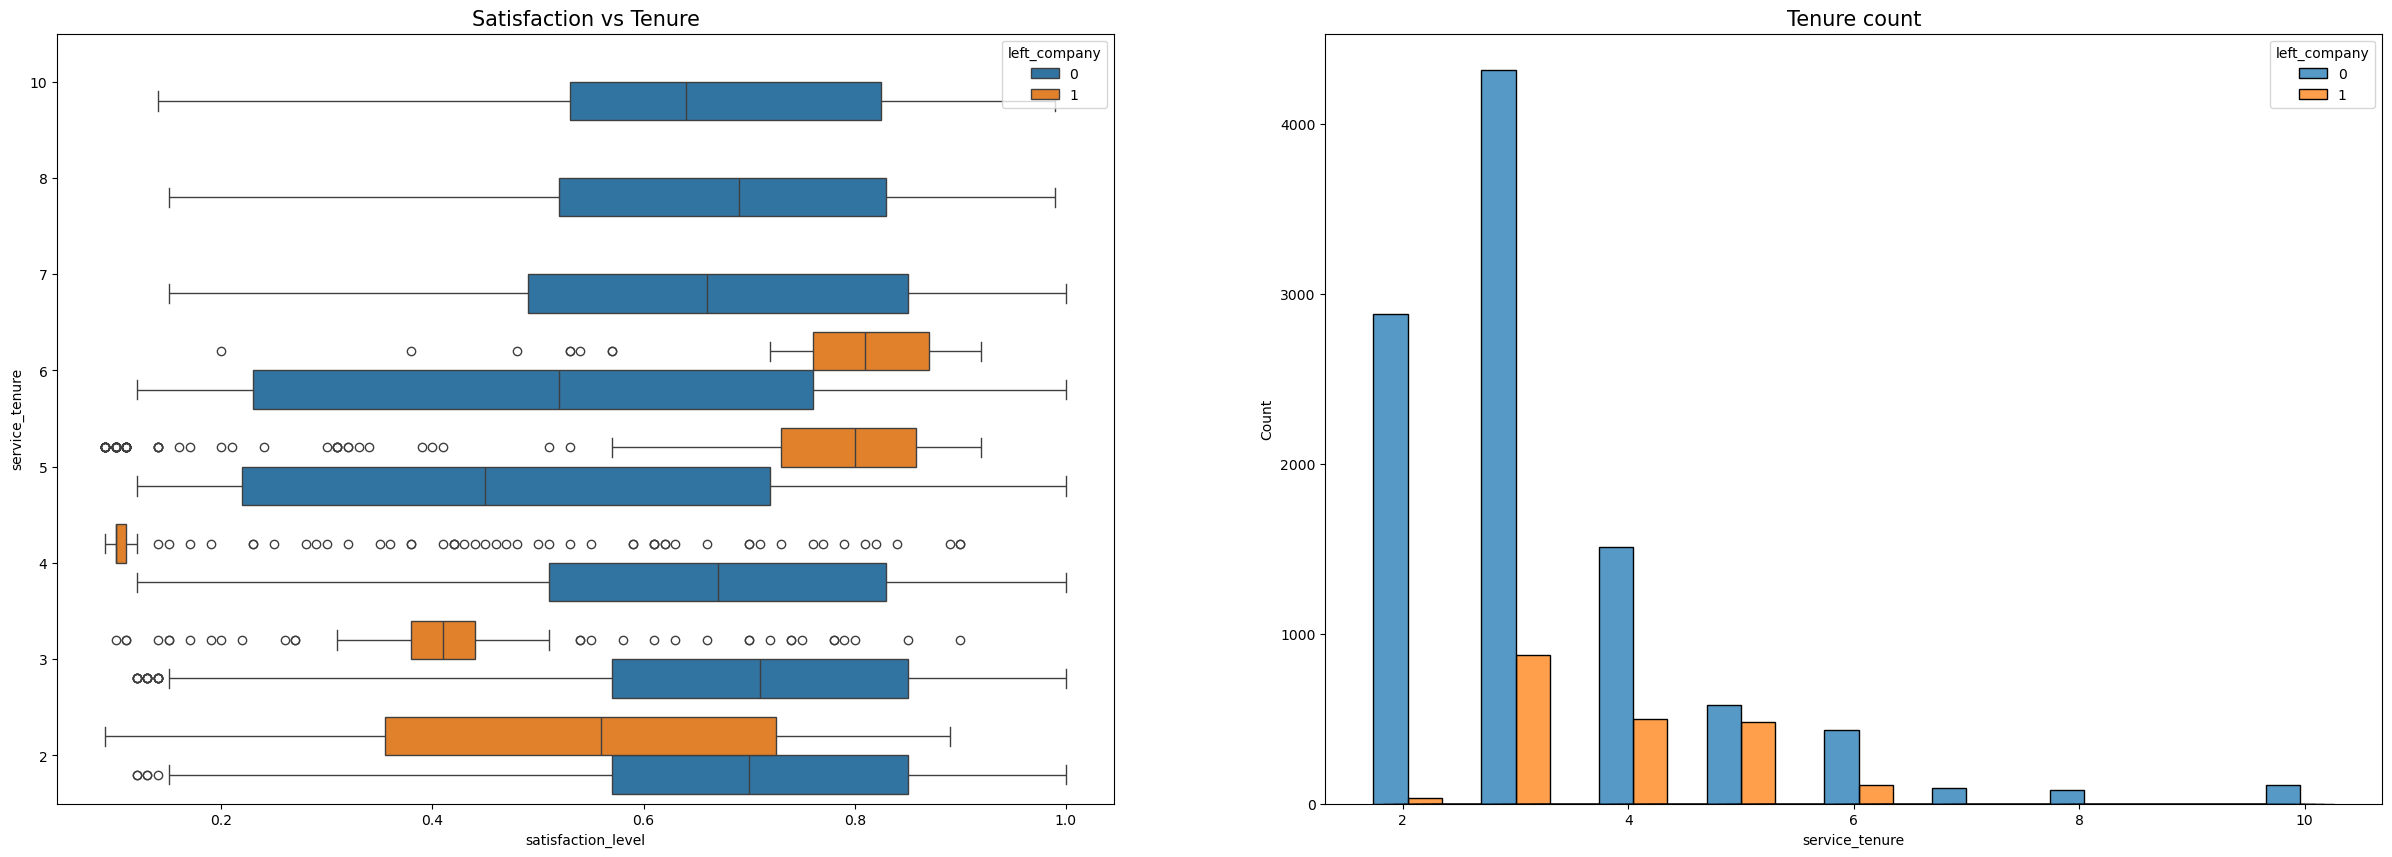

In [19]:
# Satisfaction level by tenure, and tenure counts for leavers vs stayers
fig,ax=plt.subplots(1,2,figsize=(30,10))

sns.boxplot(data=df,x='satisfaction_level',y='service_tenure',hue='left_company',orient='h',ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Satisfaction vs Tenure', fontsize='15')

sns.histplot(data=df,x='service_tenure',hue='left_company',multiple='dodge',shrink=7,ax=ax[1])
ax[1].set_title('Tenure count',fontsize='15')
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap')

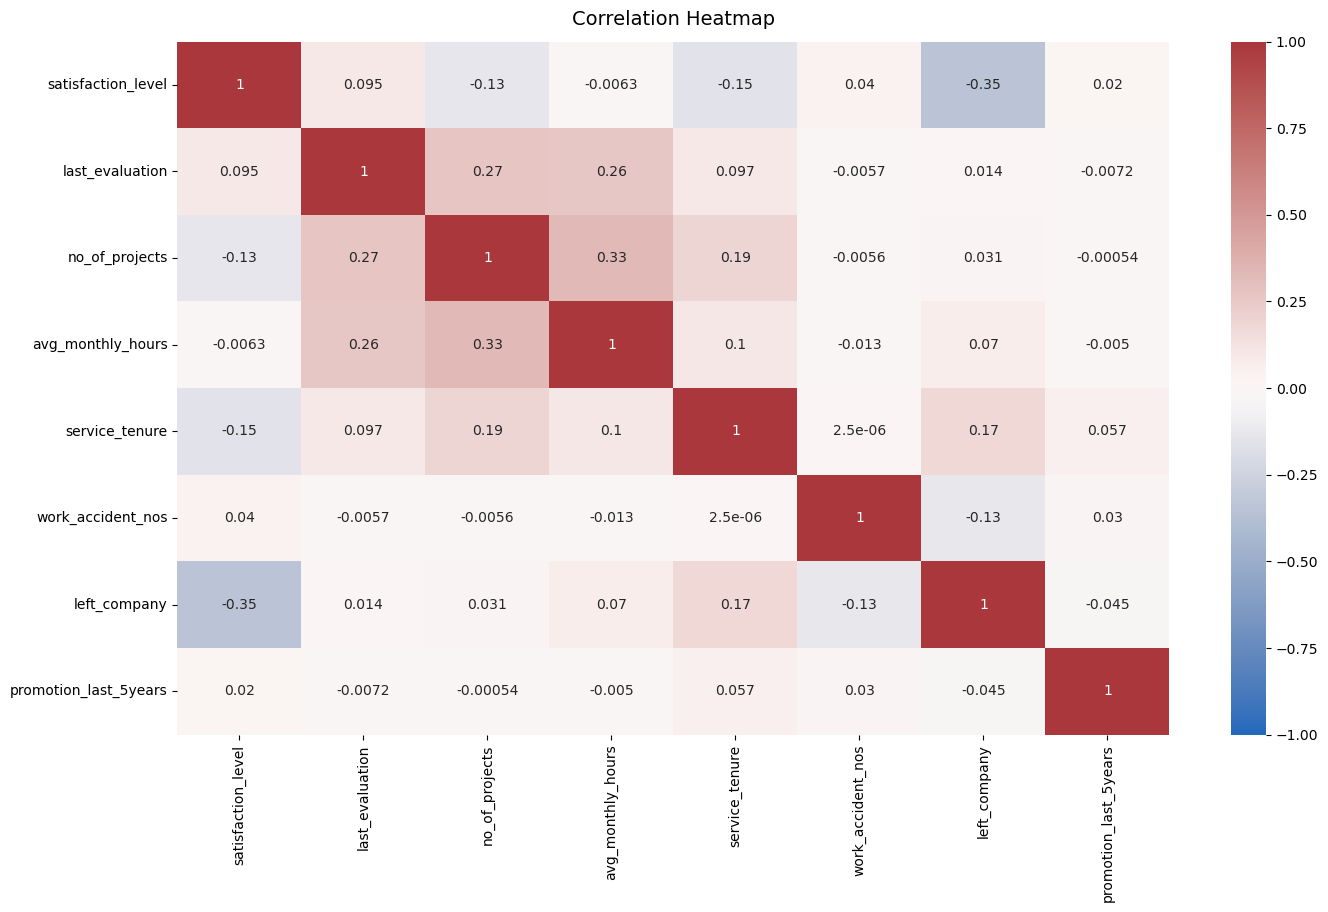

In [20]:
# Correlation heatmap of the numeric variables
plt.figure(figsize=(16, 9))
heatmap = sns.heatmap(df.corr(numeric_only=True), vmin=-1, vmax=1, annot=True, cmap=sns.color_palette("vlag", as_cmap=True))
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12)

Text(0.5, 1.0, 'Counts of stayed/left by department')

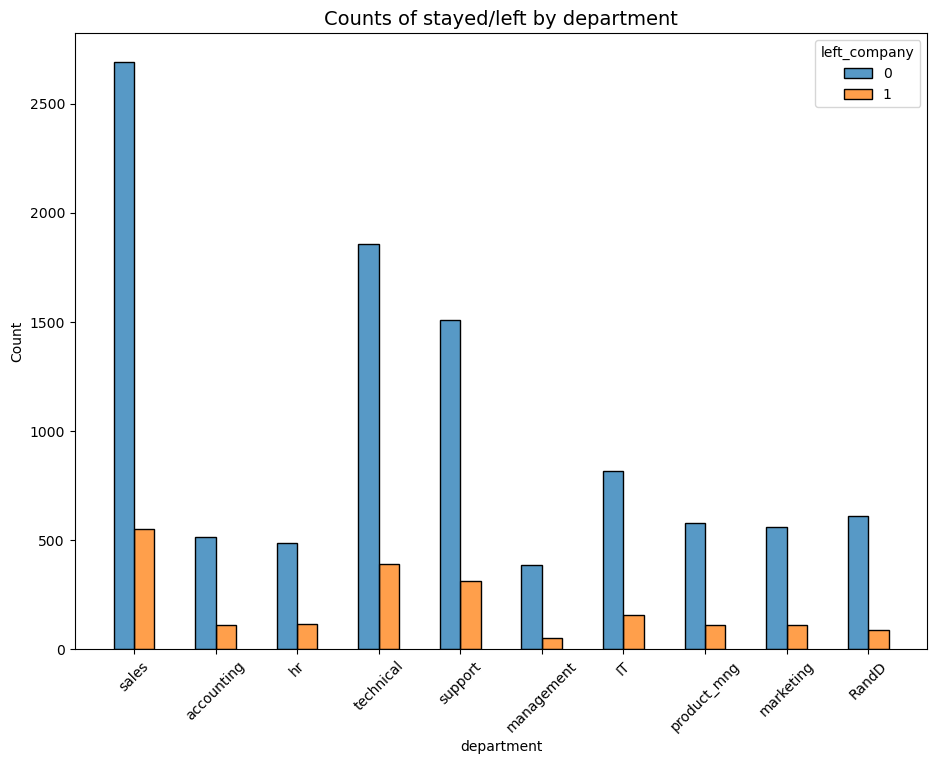

In [21]:
# Counts of employees who left vs stayed by department
plt.figure(figsize=(11,8))
sns.histplot(data=df, x='department', hue='left_company', discrete=1, 
             hue_order=[0, 1], multiple='dodge', shrink=.5)
plt.xticks(rotation=45)
plt.title('Counts of stayed/left by department', fontsize=14)

### EDA Insights

The visual analysis suggests that turnover is related to employee satisfaction, workload, number of projects, tenure, and evaluation patterns. These relationships provide useful context for interpreting the predictive models later in the notebook.


## Model Building and Evaluation


### Modeling Approach

This is a supervised binary classification problem: the target variable is whether an employee left the company. Logistic Regression, Decision Tree, and Random Forest models were evaluated, with the tree-based models offering stronger predictive performance and more interpretable feature-importance outputs.


# Logistic Regression Model

In [22]:
df_log=df.copy()
df_log['salary'] = (
    df_log['salary'].astype('category')
    .cat.set_categories(['low', 'medium', 'high'])
    .cat.codes
)
df_log = pd.get_dummies(df_log, drop_first=False)
df_log.head()

,satisfaction_level,last_evaluation,no_of_projects,avg_monthly_hours,service_tenure,work_accident_nos,left_company,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


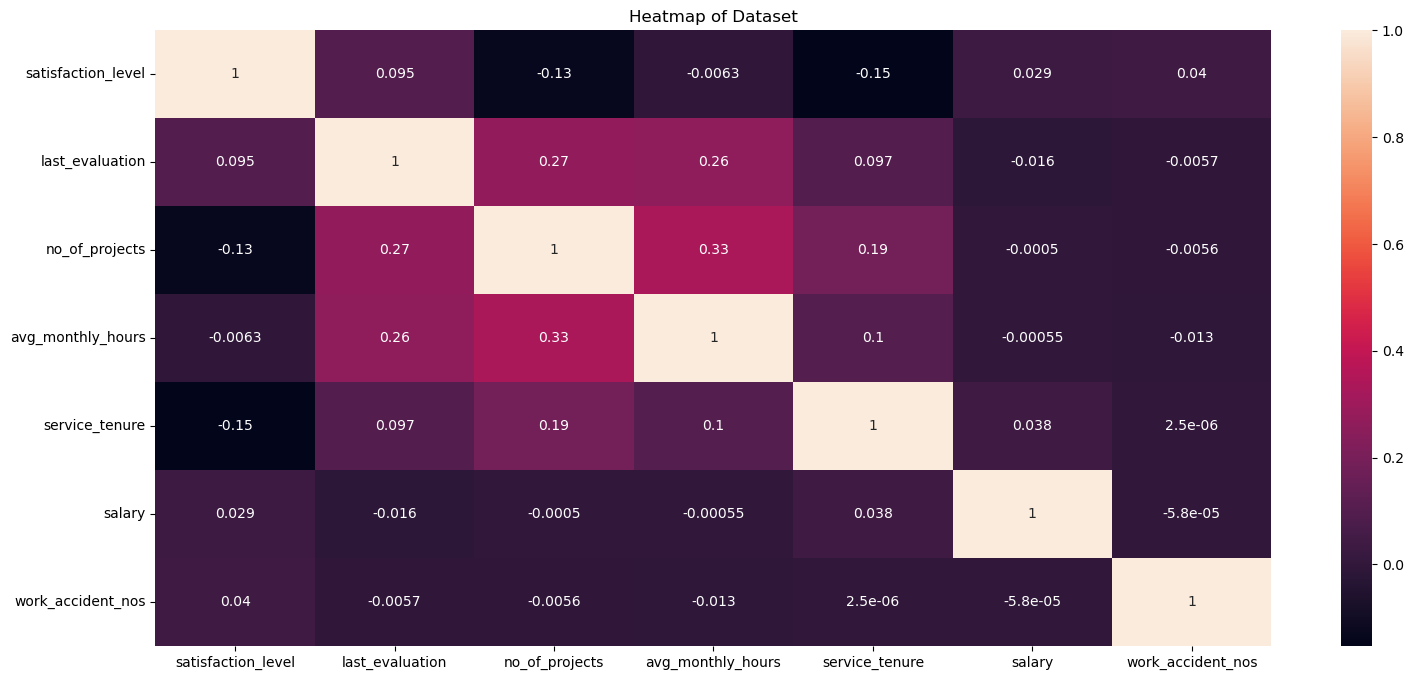

In [23]:
plt.figure(figsize=(18,8))
sns.heatmap(df_log[['satisfaction_level','last_evaluation','no_of_projects','avg_monthly_hours','service_tenure',
                    'salary','work_accident_nos']].corr(),annot=True)
plt.title('Heatmap of Dataset')
plt.show()

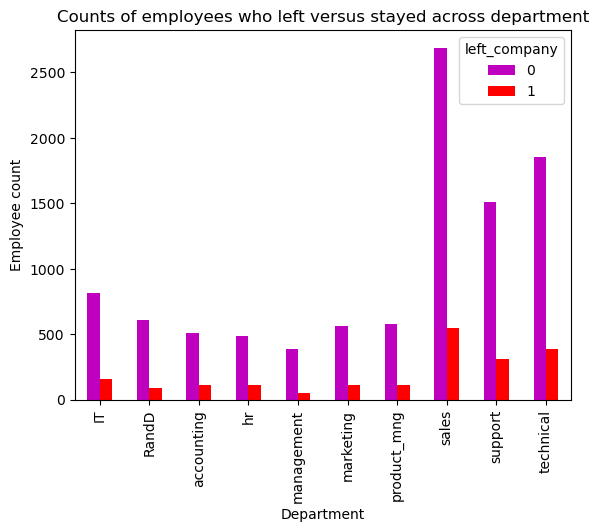

In [24]:
pd.crosstab(df['department'], df['left_company']).plot(kind ='bar',color='mr')
plt.title('Counts of employees who left versus stayed across department')
plt.ylabel('Employee count')
plt.xlabel('Department')
plt.show()

In [25]:
df_logreg=df_log[(df_log['service_tenure']>=Lower_limit)&(df_log['service_tenure']<=Upper_limit)]
df_logreg.head()

,satisfaction_level,last_evaluation,no_of_projects,avg_monthly_hours,service_tenure,work_accident_nos,left_company,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
5,0.41,0.50,2,153,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


In [26]:
y=df_logreg['left_company']
X=df_logreg.drop(columns=['left_company'])

In [27]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,stratify=y,random_state=0)

In [28]:
log_clf=LogisticRegression(random_state=0,max_iter=500).fit(X_train,y_train)

In [29]:
#pickleing
import pickle

with open('log_clf.pkl', 'wb') as f:
    pickle.dump(log_clf, f)
#to call it one should run
# with open('log_clf.pkl', 'rb') as f:
#     log_clf = pickle.load(f)

# ready to use immediately
# log_clf.predict(X_test)

In [28]:
y_pred = log_clf.predict(X_test)

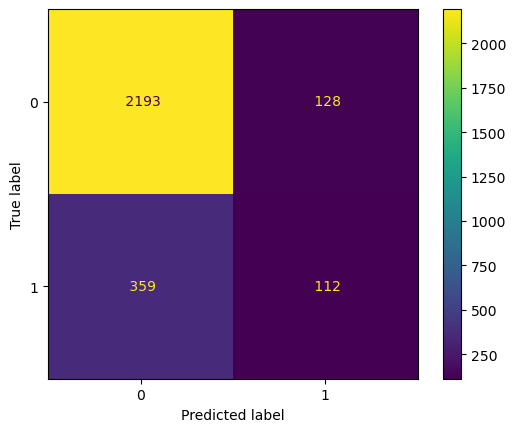

In [29]:
log_cm = confusion_matrix(y_test, y_pred, labels=log_clf.classes_)
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, display_labels=log_clf.classes_)
log_disp.plot(values_format=' ')
plt.show()

In [30]:
from sklearn.metrics import classification_report
target_names=['Might not leave','Might leave']
print(classification_report(y_test,y_pred,target_names=target_names))

                 precision    recall  f1-score   support

Might not leave       0.86      0.94      0.90      2321
    Might leave       0.47      0.24      0.32       471

       accuracy                           0.83      2792
      macro avg       0.66      0.59      0.61      2792
   weighted avg       0.79      0.83      0.80      2792



In [31]:
from sklearn.metrics import roc_auc_score

y_proba = log_clf.predict_proba(X_test)[:, 1]

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(precision, recall, f1, accuracy, auc)

0.4666666666666667 0.23779193205944799 0.3150492264416315 0.8255730659025788 0.892335374147793


# Decision Tree Model

In [32]:
y=df_log['left_company']
X=df_log.drop(columns=['left_company'])

In [33]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,stratify=y,random_state=0)

In [34]:
# Instantiate the decision tree model and set up cross-validated grid search
tree = DecisionTreeClassifier(random_state=0)
cv_params = {
    'max_depth': [4, 6, 8, None],
    'min_samples_leaf': [1, 2, 5],
    'min_samples_split': [2, 4, 6]
}
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
tree1 = GridSearchCV(tree, cv_params, scoring=scoring, cv=4, refit='roc_auc')

tree1.fit(X_train, y_train)


,estimator,DecisionTreeC...andom_state=0)
,param_grid,"{'max_depth': [4, 6, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...]}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,None
,refit,'roc_auc'
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [35]:
tree1.best_params_

{'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2}

In [36]:
tree1.best_score_

np.float64(0.969819392792457)

In [37]:
def make_results(model_name:str, model_object, metric:str):
    metric_dict = {'auc': 'mean_test_roc_auc',
                   'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy'
                  }
    
    cv_results = pd.DataFrame(model_object.cv_results_)
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]
    
    auc = best_estimator_results.mean_test_roc_auc
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy
    
    table = pd.DataFrame()
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          'AUC': [auc]
                        })
    
    return table

In [38]:
tree1_cv_results = make_results('decision tree cv', tree1, 'auc')
tree1_cv_results

,model,precision,recall,F1,accuracy,AUC
0,decision tree cv,0.914552,0.916949,0.915707,0.971978,0.969819


In [39]:
from sklearn.metrics import roc_auc_score

best_tree=tree1.best_estimator_
y_pred=best_tree.predict(X_test)
y_proba = best_tree.predict_proba(X_test)[:, 1] 

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(precision, recall, f1, accuracy, auc)

0.9362139917695473 0.9136546184738956 0.9247967479674797 0.9753168779186124 0.9780128514056226


# Random Forest Model

In [40]:
# Instantiate the random forest model and set up cross-validated grid search
rf = RandomForestClassifier(random_state=0)
cv_params = {
    'max_depth': [3, 5, None],
    'max_features': [1.0],
    'max_samples': [0.7, 1.0],
    'min_samples_leaf': [1, 2, 3],
    'min_samples_split': [2, 3, 4],
    'n_estimators': [300, 500]
}
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
rf1 = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='roc_auc')

rf1.fit(X_train, y_train)


,estimator,RandomForestC...andom_state=0)
,param_grid,"{'max_depth': [3, 5, ...], 'max_features': [1.0], 'max_samples': [0.7, 1.0], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,None
,refit,'roc_auc'
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [ ]:
#pickleing
with open('rf1.pkl', 'wb') as f:
    pickle.dump(rf1, f)
#to call it one should run
# with open('rf1.pkl', 'rb') as f:
#     rf1 = pickle.load(f)

# ready to use immediately
# rf1.predict(X_test)

In [42]:
rf1.best_score_

np.float64(0.9804250949807172)

In [43]:
rf1.best_params_

{'max_depth': 5,
 'max_features': 1.0,
 'max_samples': 0.7,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'n_estimators': 500}

In [44]:
rf1_cv_results = make_results('random forest cv', rf1, 'auc')
print(tree1_cv_results)
print(rf1_cv_results)

              model  precision    recall        F1  accuracy       AUC
0  decision tree cv   0.914552  0.916949  0.915707  0.971978  0.969819
              model  precision    recall        F1  accuracy       AUC
0  random forest cv   0.950023  0.915614  0.932467  0.977983  0.980425


In [45]:
def get_scores(model_name:str, model, X_test_data, y_test_data):
    preds = model.best_estimator_.predict(X_test_data)

    auc = roc_auc_score(y_test_data, preds)
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision], 
                          'recall': [recall],
                          'f1': [f1],
                          'accuracy': [accuracy],
                          'AUC': [auc]
                         })
  
    return table

In [46]:
rf1_test_scores = get_scores('random forest1 test', rf1, X_test, y_test)
rf1_test_scores

,model,precision,recall,f1,accuracy,AUC
0,random forest1 test,0.964211,0.919679,0.941418,0.980987,0.956439


In [47]:
best_forest=rf1.best_estimator_
y_pred=best_forest.predict(X_test)
y_proba = best_forest.predict_proba(X_test)[:, 1] 

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(precision, recall, f1, accuracy, auc)

0.9642105263157895 0.9196787148594378 0.9414182939362795 0.9809873248832555 0.9846425702811246


| Model                 | Precision | Recall | F1     | Accuracy | AUC    |
|-----------------------|-----------|--------|--------|----------|--------|
| Logistic Regression\* | 0.4667 | 0.2378 | 0.3150 | 0.8256 | 0.8923 |
| Decision Tree         | 0.9362 | 0.9137 | 0.9248 | 0.9753 | 0.9780 |
| Random Forest         | 0.9642 | 0.9197 | 0.9414 | 0.9810 | 0.9846 |

\*Logistic regression was trained and evaluated on the outlier-removed dataset.

### Random Forest Feature Importance

The Random Forest model identifies which variables contributed most to its turnover predictions. Because feature importance values are relative, the chart below should be interpreted as model weighting rather than direct causation.


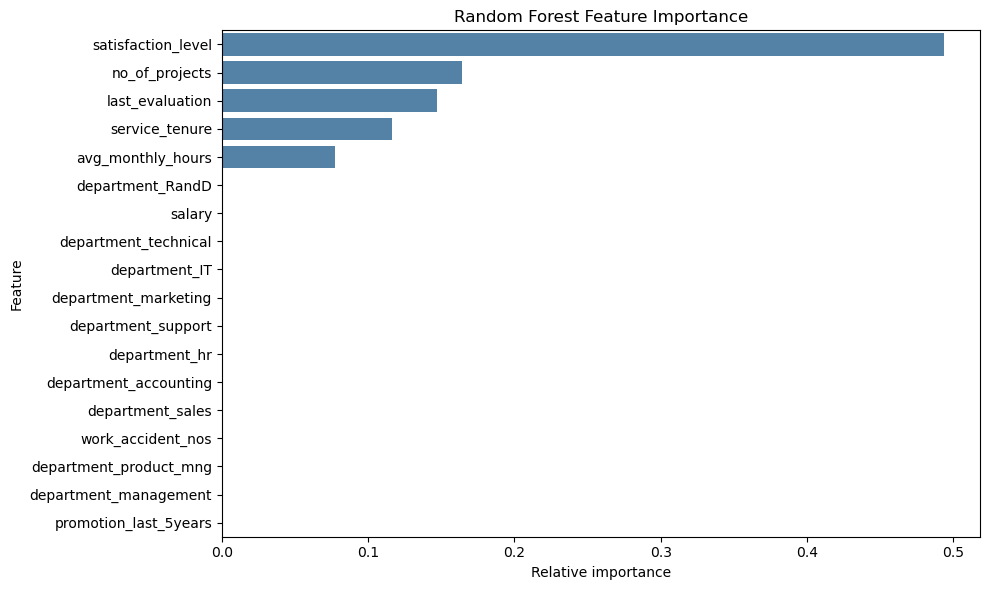

satisfaction_level        0.493518
no_of_projects            0.164313
last_evaluation           0.146839
service_tenure            0.116408
avg_monthly_hours         0.077554
department_RandD          0.000244
salary                    0.000209
department_technical      0.000181
department_IT             0.000152
department_marketing      0.000151
department_support        0.000125
department_hr             0.000122
department_accounting     0.000095
department_sales          0.000053
work_accident_nos         0.000013
department_product_mng    0.000010
department_management     0.000010
promotion_last_5years     0.000002
dtype: float64

In [48]:
# Plot feature importance for the best Random Forest model
rf_importances = (
    pd.Series(best_forest.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=rf_importances.values, y=rf_importances.index, color='steelblue')
plt.title('Random Forest Feature Importance')
plt.xlabel('Relative importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

rf_importances


**Interpretation:** The highest-weighted variables show which employee attributes the Random Forest used most when separating employees likely to leave from those likely to stay. In this project, the top drivers should be discussed alongside the earlier EDA: satisfaction, evaluation results, project load, monthly hours, and tenure are especially useful for framing retention recommendations.


## Final Summary and Recommendations


### Model Performance Summary

The Random Forest model performed best overall, with strong precision, recall, F1, accuracy, and AUC scores. Compared with the Decision Tree, the Random Forest achieved higher precision, F1, accuracy, and AUC, making it the stronger model for identifying employees at risk of leaving.


### Key Takeaways

- Employee turnover appears strongly connected to satisfaction, workload, project count, tenure, and evaluation patterns.
- The Random Forest model was the best-performing model, with an AUC of approximately 0.9846 and accuracy of approximately 0.9810.
- Feature importance helps explain which variables the model relied on most, but these values should be interpreted as model weighting rather than proof of direct causation.
- The results point toward retention strategies focused on workload balance, employee satisfaction, career development, and early intervention for high-risk employee groups.


### Recommendations and Next Steps

Salifort Motors should monitor satisfaction, project load, monthly hours, tenure, and recent evaluation patterns to identify employees who may be at higher risk of leaving. Managers can use these signals to review workload balance, improve recognition and career-growth opportunities, and design targeted retention conversations before employees disengage.

Next steps include validating the model on newer employee data, reviewing feature importance with HR stakeholders, adding qualitative feedback such as survey comments or manager notes, and using the model as a decision-support tool rather than as the sole basis for HR decisions. Ethical use is important: predictions should support employee well-being and fair treatment, not punitive action.
